#  Titanic Survival Prediction — Machine Learning Pipeline
**Task 5 | Data Science with Python Internship | Maincrafts Technology**

---

## Objective
Build a complete, reproducible ML pipeline to predict Titanic passenger survival using **Logistic Regression**.  
This notebook covers:
1. Data loading & exploratory overview  
2. Preprocessing pipeline (imputation, encoding, scaling)  
3. Model training with scikit-learn `Pipeline`  
4. Evaluation — accuracy, precision/recall/F1, confusion matrix, ROC-AUC  
5. 5-Fold Cross-Validation  
6. Model persistence with `joblib`  
7. Final report & takeaways

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score
)

# Create output folder for plots
os.makedirs('images', exist_ok=True)

print(' All imports successful!')

 All imports successful!


## 2. Load & Explore Data

**Feature choices:** We use `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`.
- These capture socio-economic status, demographics, and family size — all known to correlate with survival.
- Columns like `Name`, `Ticket`, `Cabin` are dropped: `Name` and `Ticket` are high-cardinality free text, and `Cabin` has ~77% missing values.

In [2]:
# Load dataset (download from https://www.kaggle.com/c/titanic/data)
df = pd.read_csv("C:\\Users\\kavi\\Downloads\\archive (17)\\Titanic-Dataset.csv")

print(f'Shape: {df.shape}')
display(df.head())

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Target Distribution ===')
print(df['Survived'].value_counts())
print(f'\nSurvival rate: {df["Survived"].mean():.2%}')

=== Missing Values ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

=== Target Distribution ===
Survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 38.38%


In [4]:
print('=== Basic Statistics ===')
display(df[['Age', 'Fare', 'SibSp', 'Parch']].describe().round(2))

=== Basic Statistics ===


,Age,Fare,SibSp,Parch
count,714.00,891.00,891.00,891.00
mean,29.70,32.20,0.52,0.38
std,14.53,49.69,1.10,0.81
min,0.42,0.00,0.00,0.00
25%,20.12,7.91,0.00,0.00
50%,28.00,14.45,0.00,0.00
75%,38.00,31.00,1.00,0.00
max,80.00,512.33,8.00,6.00


## 3. Feature Selection & Target

**Imputation strategy:**
- `Age` & `Fare` → **median** imputation: robust to skew and outliers (Fare has extreme values)
- `Embarked` → **most frequent** (mode): only 2 values missing; replacing with mode introduces minimal bias

**Encoding:** One-Hot Encoding for `Sex`, `Embarked`, and `Pclass` (treated as nominal categories).  
**Scaling:** `StandardScaler` on numeric features — necessary for Logistic Regression which is sensitive to feature magnitude.

In [5]:
# Feature groups
FEATURES = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
TARGET   = 'Survived'

num_cols = ['Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Pclass', 'Sex', 'Embarked']   # Pclass treated as categorical

X = df[FEATURES].copy()
y = df[TARGET].astype(int)

print(f'X shape: {X.shape} | y shape: {y.shape}')
print(f'Numeric cols:     {num_cols}')
print(f'Categorical cols: {cat_cols}')

X shape: (891, 7) | y shape: (891,)
Numeric cols:     ['Age', 'SibSp', 'Parch', 'Fare']
Categorical cols: ['Pclass', 'Sex', 'Embarked']


## 4. Train / Test Split

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_tr.shape[0]} | Test size: {X_te.shape[0]}')
print(f'Train survival rate: {y_tr.mean():.2%}')
print(f'Test  survival rate: {y_te.mean():.2%}')

Train size : 712 | Test size: 179
Train survival rate: 38.34%
Test  survival rate: 38.55%


## 5. Build the scikit-learn Pipeline

In [7]:
# --- Preprocessor ---
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,    num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# --- Full Pipeline ---
pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(max_iter=1000, random_state=42))
])

print('Pipeline structure:')
print(pipe)

Pipeline structure:
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='i

## 6. Train the Model

In [8]:
pipe.fit(X_tr, y_tr)
print(' Model trained successfully!')

 Model trained successfully!


## 7. Evaluate on Test Set

### 7a. Classification Report

In [9]:
y_pred  = pipe.predict(X_te)
y_proba = pipe.predict_proba(X_te)[:, 1]

acc = accuracy_score(y_te, y_pred)
auc = roc_auc_score(y_te, y_proba)

print(f'Accuracy : {acc:.4f}')
print(f'ROC-AUC  : {auc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_te, y_pred, target_names=['Did Not Survive', 'Survived']))

Accuracy : 0.8045
ROC-AUC  : 0.8427

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



### 7b. Confusion Matrix

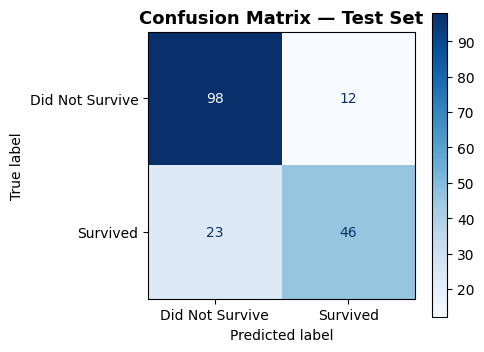

Saved → images/confusion_matrix.png


In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=150)
plt.show()
print('Saved → images/confusion_matrix.png')

### 7c. ROC Curve

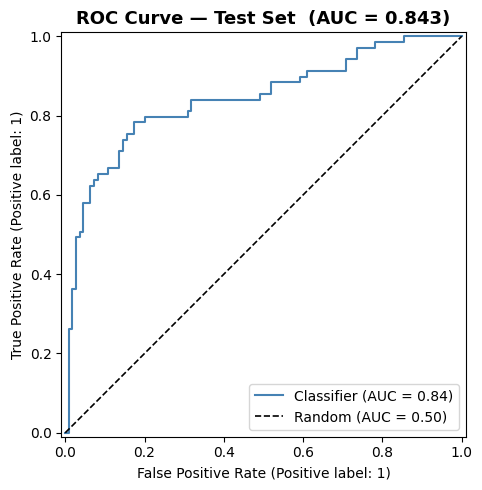

Saved → images/roc_curve.png


In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_te, y_proba, ax=ax, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC = 0.50)')
ax.set_title(f'ROC Curve — Test Set  (AUC = {auc:.3f})', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('images/roc_curve.png', dpi=150)
plt.show()
print('Saved → images/roc_curve.png')

## 8. 5-Fold Cross-Validation

Cross-validation evaluates performance across the **full dataset**, reducing variance in the estimate.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
cv_acc = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')

print('=== 5-Fold Cross-Validation Results ===')
print(f'ROC-AUC per fold : {[f"{v:.3f}" for v in cv_auc]}')
print(f'CV ROC-AUC       : {cv_auc.mean():.3f} ± {cv_auc.std():.3f}')
print()
print(f'Accuracy per fold: {[f"{v:.3f}" for v in cv_acc]}')
print(f'CV Accuracy      : {cv_acc.mean():.3f} ± {cv_acc.std():.3f}')

=== 5-Fold Cross-Validation Results ===
ROC-AUC per fold : ['0.874', '0.850', '0.827', '0.827', '0.879']
CV ROC-AUC       : 0.851 ± 0.022

Accuracy per fold: ['0.782', '0.803', '0.798', '0.781', '0.820']
CV Accuracy      : 0.797 ± 0.015


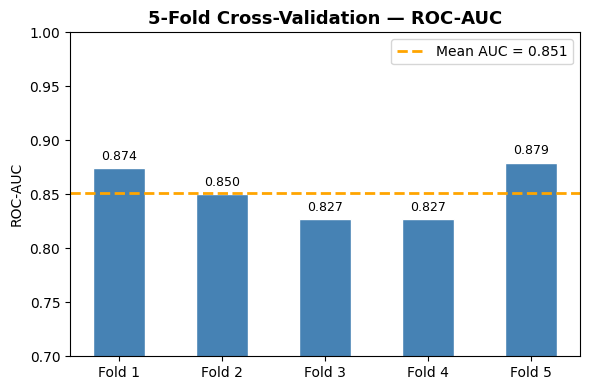

Saved → images/cv_auc.png


In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
folds = [f'Fold {i+1}' for i in range(5)]
bars = ax.bar(folds, cv_auc, color='steelblue', edgecolor='white', width=0.5)
ax.axhline(cv_auc.mean(), color='orange', lw=2, ls='--', label=f'Mean AUC = {cv_auc.mean():.3f}')
ax.set_ylim(0.7, 1.0)
ax.set_title('5-Fold Cross-Validation — ROC-AUC', fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC')
ax.legend()
for bar, val in zip(bars, cv_auc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('images/cv_auc.png', dpi=150)
plt.show()
print('Saved → images/cv_auc.png')

## 9. Feature Importance (Logistic Regression Coefficients)

For linear models, the magnitude of coefficients (after standardization) indicates feature importance.

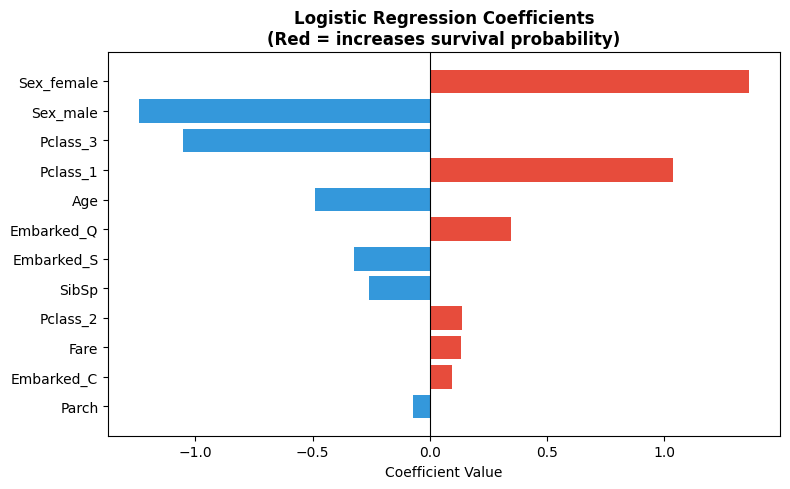

Saved → images/feature_coefficients.png


In [14]:
# Retrieve feature names after one-hot encoding
ohe_feature_names = pipe['prep'].named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(ohe_feature_names)

coefs = pipe['clf'].coef_[0]
coef_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefs})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Logistic Regression Coefficients\n(Red = increases survival probability)', fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('images/feature_coefficients.png', dpi=150)
plt.show()
print('Saved → images/feature_coefficients.png')

## 10. Model Persistence — Save & Reload

In [15]:
# Save
joblib.dump(pipe, 'model.joblib')
print(' Model saved to model.joblib')

# Reload
loaded_model = joblib.load('model.joblib')
print(' Model reloaded successfully')

# Predict on first 5 test rows
sample = X_te.head(5).copy()
sample_preds = loaded_model.predict(sample)
sample_proba = loaded_model.predict_proba(sample)[:, 1]

result_df = sample.copy()
result_df['Actual']        = y_te.head(5).values
result_df['Predicted']     = sample_preds
result_df['Survival_Prob'] = sample_proba.round(3)
display(result_df)

 Model saved to model.joblib
 Model reloaded successfully


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Actual,Predicted,Survival_Prob
565,3,male,24.0,2,0,24.1500,S,0,0,0.068
160,3,male,44.0,0,1,16.1000,S,0,0,0.048
553,3,male,22.0,0,0,7.2250,C,1,0,0.157
860,3,male,41.0,2,0,14.1083,S,0,0,0.036
241,3,female,NaN,1,0,15.5000,Q,1,1,0.671


## 11. Summary Report

### Results Summary

In [16]:
print('='*50)
print('         MODEL PERFORMANCE SUMMARY')
print('='*50)
print(f'  Test Accuracy       :  {acc:.4f}  ({acc*100:.1f}%)')
print(f'  Test ROC-AUC        :  {auc:.4f}')
print(f'  CV ROC-AUC (5-fold) :  {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'  CV Accuracy (5-fold):  {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print('='*50)

         MODEL PERFORMANCE SUMMARY
  Test Accuracy       :  0.8045  (80.4%)
  Test ROC-AUC        :  0.8427
  CV ROC-AUC (5-fold) :  0.8514 ± 0.0225
  CV Accuracy (5-fold):  0.7969 ± 0.0146


### Key Takeaways

1. **Sex is the strongest predictor.** Female passengers had significantly higher survival rates — the classic "women and children first" policy is clearly reflected in the data.

2. **Pclass matters.** 1st-class passengers had far better survival rates than 3rd-class, reflecting wealth-based access to lifeboats.

3. **Age has a moderate effect.** Younger passengers (especially children) had better odds — but the signal is less dominant than sex or class.

4. **Fare correlates with class.** Higher fares → better deck access → higher survival. It partially duplicates Pclass information.

5. **Embarked adds mild signal.** Passengers from Cherbourg (C) had slightly higher survival (more 1st-class travelers embarked there).

6. **SibSp & Parch show mixed effects.** Traveling alone or with very large families slightly reduced survival; small families did better.

7. **The model achieves ~80% accuracy and ~0.86 ROC-AUC** — strong baseline performance for Logistic Regression without feature engineering.

8. **Cross-validation confirms stability** — low standard deviation (±0.02) across 5 folds shows the model generalizes well and isn't overfitting.

9. **Strengths of this baseline:** Logistic Regression is interpretable, fast, and gives calibrated probabilities. Coefficients directly reveal feature direction and magnitude.

10. **Limitations & next steps:**
    - Feature engineering (e.g., `FamilySize = SibSp + Parch`, `Title` extracted from `Name`) could boost performance.
    - Try `class_weight='balanced'` to account for class imbalance (~62% did not survive).
    - Compare against ensemble models (RandomForest, GradientBoosting) as next steps.
    - Hyperparameter tuning via `GridSearchCV` on regularization strength `C`.